In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import json
import os

In [2]:
raw_files = ["kariyer.jsonl", "techcareer.jsonl", "youthall.jsonl", "indeed.jsonl", "linkedin.jsonl"]
raw_data = []

for file in raw_files:
    path = f"../data/raw/{file}"
    if os.path.exists(path):
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    raw_data.append(json.loads(line))

df_raw = pd.DataFrame(raw_data)
print(f"Total Number of Raw Listings: {len(df_raw)}")

Total Number of Raw Listings: 2309


In [3]:
df_raw.shape

(2309, 12)

In [4]:
df_raw.head()

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Withdrawal_Date,Required_Skills,Posting_Type
0,Kariyer.net,veri bilimi,AR-GE Analitik Geliştirme Uzmanı,Vem İlaç San. ve Tic. A.Ş.,Kırklareli\nİş Yerinde,Not specified,"VEM İlaç, merkezi İstanbul’da bulunan, %100 ye...",https://www.kariyer.net/is-ilani/vem-ilac-san-...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
1,Kariyer.net,veri bilimi,Yapay Zeka (Aı) Proje Uzmanı,Arıkan Mağazacılık,İstanbul\nİş Yerinde,Not specified,Arıkan Group olarak portföyümüzde var olan her...,https://www.kariyer.net/is-ilani/arikan-magaza...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
2,Kariyer.net,veri bilimi,Veri Yönetimi ve Analitiği Koordinatörü,Lokman Hekim Sağlık Grubu,Ankara\nİş Yerinde,Not specified,Lokman Hekim Üniversitesi Araştırma Dekanlığı ...,https://www.kariyer.net/is-ilani/lokman-hekim-...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
3,Kariyer.net,veri bilimi,Bilgi İşlem Uzmanı,Akasya Çocuk Dünyası A.Ş.,İstanbul(Asya)\nİş Yerinde,Not specified,"Biz KidZania İstanbul’da, “eğlenerek öğrenme” ...",https://www.kariyer.net/is-ilani/akasya-cocuk-...,https://img-kariyer.mncdn.com/mnresize/150/150...,2026-07-19,NaN,NaN
4,Kariyer.net,veri bilimi,Sürdürülebilirlik Ofisi Uzmanı,İzmir Ekonomi Üniversitesi,İzmir\nİş Yerinde,Not specified,İzmir Ekonomi Üniversitesi Sürdürülebilirlik O...,https://www.kariyer.net/is-ilani/izmir-ekonomi...,"data:image/svg+xml;charset=UTF-8,%3Csvg%20widt...",2026-07-19,NaN,NaN


In [5]:
df_raw.tail()

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Withdrawal_Date,Required_Skills,Posting_Type
2304,LinkedIn,software test,Customer Support Field Engineer,Panasonic Avionics Corporation,Arnavutköy,Not specified,Overview\n\nWho We Are: \n\nEver wonder who br...,https://tr.linkedin.com/jobs/view/customer-sup...,https://media.licdn.com/dms/image/v2/D560BAQH6...,2026-07-19,NaN,NaN
2305,LinkedIn,software test,"Senior Software Engineer (AI, Python, AWS)",Confidential Jobs,Türkiye,Not specified,About the Role:\n\nWe are seeking a highly aut...,https://tr.linkedin.com/jobs/view/senior-softw...,https://media.licdn.com/dms/image/v2/C4E0BAQEi...,2026-07-19,NaN,NaN
2306,LinkedIn,software test,Senior Engine Calibration Engineer,Ford Otosan,"İstanbul, Türkiye",Not specified,Ford Otosan şirketinde iş ilanını yayınlayan k...,https://tr.linkedin.com/jobs/view/senior-engin...,https://media.licdn.com/dms/image/v2/D4D0BAQF3...,2026-07-19,NaN,NaN
2307,LinkedIn,software test,Optical System Engineer,Kastamonu Entegre,"İstanbul, Türkiye",Not specified,Kastamonu Entegre şirketinde iş ilanını yayınl...,https://tr.linkedin.com/jobs/view/optical-syst...,https://media.licdn.com/dms/image/v2/D4D0BAQHJ...,2026-07-19,NaN,NaN
2308,LinkedIn,software test,System Integration Manager,Vodafone,Greater Istanbul,Not specified,"Join Us\n\nAt Vodafone, we’re not just shaping...",https://tr.linkedin.com/jobs/view/system-%C4%B...,https://media.licdn.com/dms/image/v2/C560BAQGA...,2026-07-19,NaN,NaN


In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 2309 entries, 0 to 2308
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Platform          2309 non-null   str  
 1   Search_Keyword    2128 non-null   str  
 2   Job_Title         2309 non-null   str  
 3   Company           2309 non-null   str  
 4   Location_Details  2309 non-null   str  
 5   Job_Type          2257 non-null   str  
 6   Job_Description   2309 non-null   str  
 7   Job_Link          2309 non-null   str  
 8   Logo_Link         2309 non-null   str  
 9   Withdrawal_Date   2309 non-null   str  
 10  Required_Skills   129 non-null    str  
 11  Posting_Type      52 non-null     str  
dtypes: str(12)
memory usage: 216.6 KB


In [7]:
df_raw.describe(include='all').T

,count,unique,top,freq
Platform,2309,5,LinkedIn,1069
Search_Keyword,2128,22,yapay zeka,257
Job_Title,2309,1696,Yazılım Mühendisi,17
Company,2309,1211,"EPAM Systems, Inc.",51
Location_Details,2309,219,İstanbul,376
Job_Type,2257,34,Not specified,1494
Job_Description,2309,2167,Description could not be retrieved,40
Job_Link,2309,2309,https://www.kariyer.net/is-ilani/vem-ilac-san-...,1
Logo_Link,2309,738,No Logo,663
Withdrawal_Date,2309,1,2026-07-19,2309


In [8]:
df_raw.duplicated().sum()

np.int64(0)

In [9]:
df_raw.isnull().sum()

Platform               0
Search_Keyword       181
Job_Title              0
Company                0
Location_Details       0
Job_Type              52
Job_Description        0
Job_Link               0
Logo_Link              0
Withdrawal_Date        0
Required_Skills     2180
Posting_Type        2257
dtype: int64

In [10]:
df_raw['Job_Type'].value_counts()

Job_Type
Not specified                                 1494
                                               454
Tam zamanlı                                    130
İş Yerinde                                     102
Asya / Türkiye                                  17
Tam zamanlı +1                                  13
Hibrit                                           8
Yarı zamanlı +1                                  7
₺30.000 - ₺500.000/ay                            2
₺35.000 - ₺45.000/ay                             2
En az ₺45.000/ay - Tam zamanlı                   2
Kontratlı                                        2
En az ₺30.000/ay - Tam zamanlı                   2
Yarı zamanlı                                     2
Uzaktan                                          1
Avr. / Türkiye                                   1
₺580.000 - ₺1.130.000/yıl - Tam zamanlı +1       1
₺35.000 - ₺60.000/ay - Tam zamanlı +2            1
₺45.000 - ₺50.000/ay - Tam zamanlı +1            1
Geçici                

In [11]:
df_raw['Required_Skills'].value_counts()

Required_Skills
Analitik Düşünme                                                                                                                                                                             4
LAN, WAN (Geniş Alan Ağı), Siber Güvenlik, WAN Optimizasyonu, Pci Dss                                                                                                                        1
JavaScript, REST API, Veritabanı Sistemler, Frontend, Optimizasyon, Web Yazılım, PHP                                                                                                         1
Power BI, Raporlama                                                                                                                                                                          1
Sözlü iletişim, Hızlı Öğrenme, Öğrenmeye Açık, Uyumlu                                                                                                                                        1
                             

In [12]:
df_raw['Posting_Type'].value_counts()        

Posting_Type
Talent Program / Internship    44
Job Posting                     8
Name: count, dtype: int64

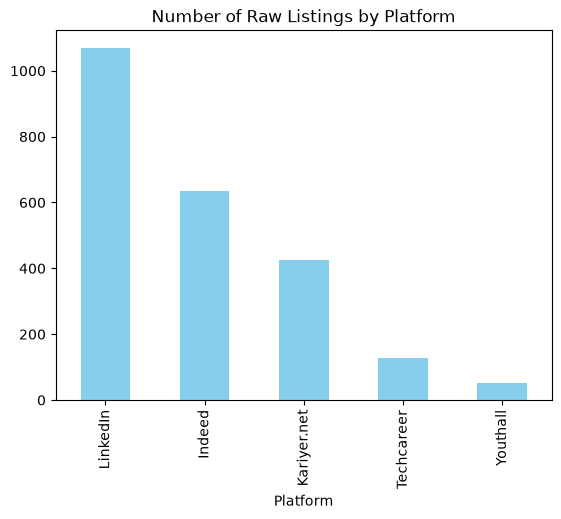

In [13]:
df_raw['Platform'].value_counts().plot(kind='bar', color='skyblue', title='Number of Raw Listings by Platform')
plt.show()

In [14]:
df_clean = pd.read_csv("../data/processed/cleaned_data.csv")
print(f"Number of Cleaned Ads: {len(df_clean)}")

Number of Cleaned Ads: 1951


In [15]:
df_clean.sample(n=5)

,Platform,Search_Keyword,Job_Title,Company,Location_Details,Job_Type,Job_Description,Job_Link,Logo_Link,Withdrawal_Date,Required_Skills,Work_Model,Experience_Level
993,LinkedIn,machine learning,Business and Management Specialist – Freelance...,"Meridial Marketplace, by Invisible",Not specified,Freelance,Are you interested in business and management ...,https://tr.linkedin.com/jobs/view/business-and...,https://media.licdn.com/dms/image/v2/D4D0BAQHx...,2026-07-19,Not specified,On-site,Senior
1790,LinkedIn,software developer,Frontend Developer,BGTS International,Not specified,Full-time,BGTS is a software and technology solutions co...,https://tr.linkedin.com/jobs/view/frontend-dev...,https://media.licdn.com/dms/image/v2/D4D0BAQF6...,2026-07-19,"java, javascript, typescript, react, angular",On-site,Not specified
1300,LinkedIn,data scientist,AI Trainer - Freelance Data Annotator,Toloka Annotators,Not specified,Freelance,Please submit your resume in English and indic...,https://tr.linkedin.com/jobs/view/a%C4%B1-trai...,https://media.licdn.com/dms/image/v2/D4D0BAQHT...,2026-07-19,Not specified,On-site,Lead/Manager
743,LinkedIn,veri analisti,Remote Business Analyst,Turing,Not specified,Full-time,"About Turing:\n\nBased in San Francisco, Calif...",https://tr.linkedin.com/jobs/view/remote-busin...,https://media.licdn.com/dms/image/v2/D4D0BAQEM...,2026-07-19,git,On-site,Lead/Manager
1538,LinkedIn,qa engineer,Vehicle Test Engineer,UBIQUITY SERVICE,İstanbul,Full-time,Вот Профессиональный Job Description На Англий...,https://tr.linkedin.com/jobs/view/vehicle-test...,https://media.licdn.com/dms/image/v2/D4E0BAQF7...,2026-07-19,Not specified,On-site,Lead/Manager


In [21]:
df_clean.columns

Index(['Platform', 'Search_Keyword', 'Job_Title', 'Company',
       'Location_Details', 'Job_Type', 'Job_Description', 'Job_Link',
       'Logo_Link', 'Withdrawal_Date', 'Required_Skills', 'Work_Model',
       'Experience_Level'],
      dtype='str')

In [16]:
df_clean['Experience_Level'].value_counts()

Experience_Level
Lead/Manager     654
Not specified    615
Senior           435
Mid-Level        152
Junior            95
Name: count, dtype: int64

In [17]:
df_clean['Job_Title'].value_counts()

Job_Title
Software Engineer                                       15
Yazılım Mühendisi                                       13
Senior Backend Developer                                11
Data Analyst                                            11
Yazılım Uzmanı                                          11
                                                        ..
Bilimsel Yazılım Geliştirme Mühendisi                    1
Senior\Regular GIS Java Developer                        1
Part time Working Student (Production engineer)          1
Senior Salesforce Developer                              1
Software Engineering Lead – Conversational Platforms     1
Name: count, Length: 1552, dtype: int64

C:\Users\HP\AppData\Local\Temp\ipykernel_6644\503496978.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_companies.index, x=top_companies.values, palette="viridis")


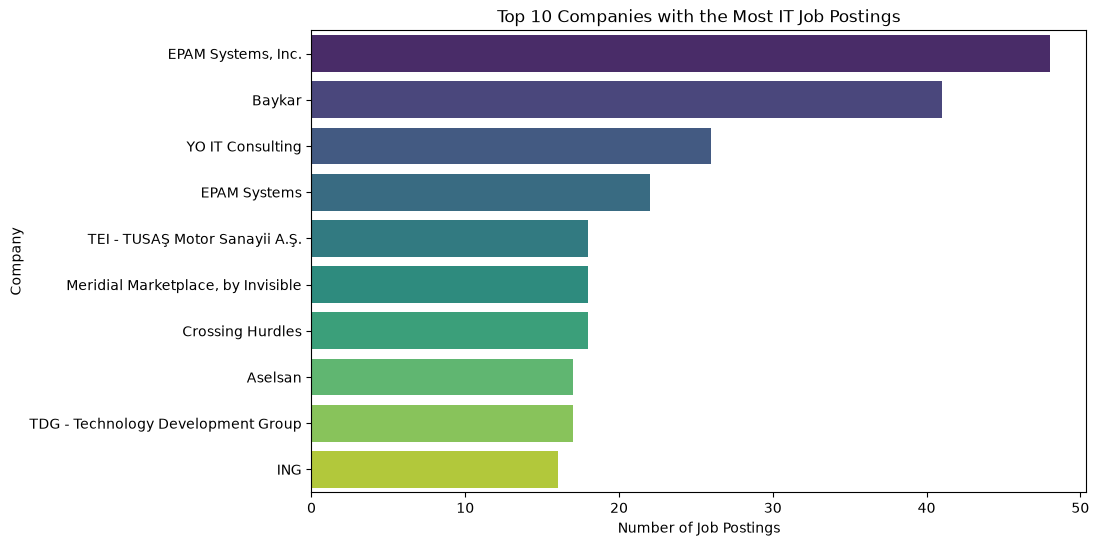

In [18]:
plt.figure(figsize=(10, 6))
top_companies = df_clean['Company'].value_counts().head(10)
sns.barplot(y=top_companies.index, x=top_companies.values, palette="viridis")
plt.title("Top 10 Companies with the Most IT Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.show()

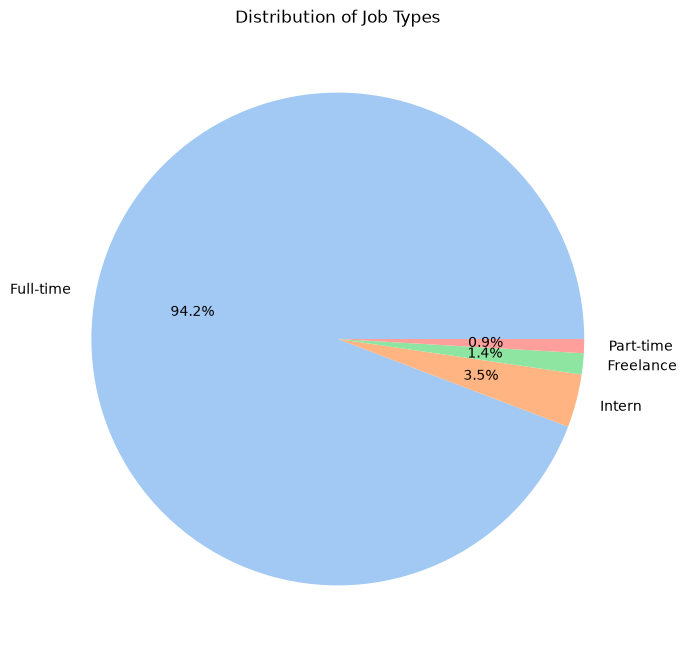

In [19]:
plt.figure(figsize=(8, 8))
job_types = df_clean['Job_Type'].value_counts()
plt.pie(job_types.values, labels=job_types.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Distribution of Job Types")
plt.show()

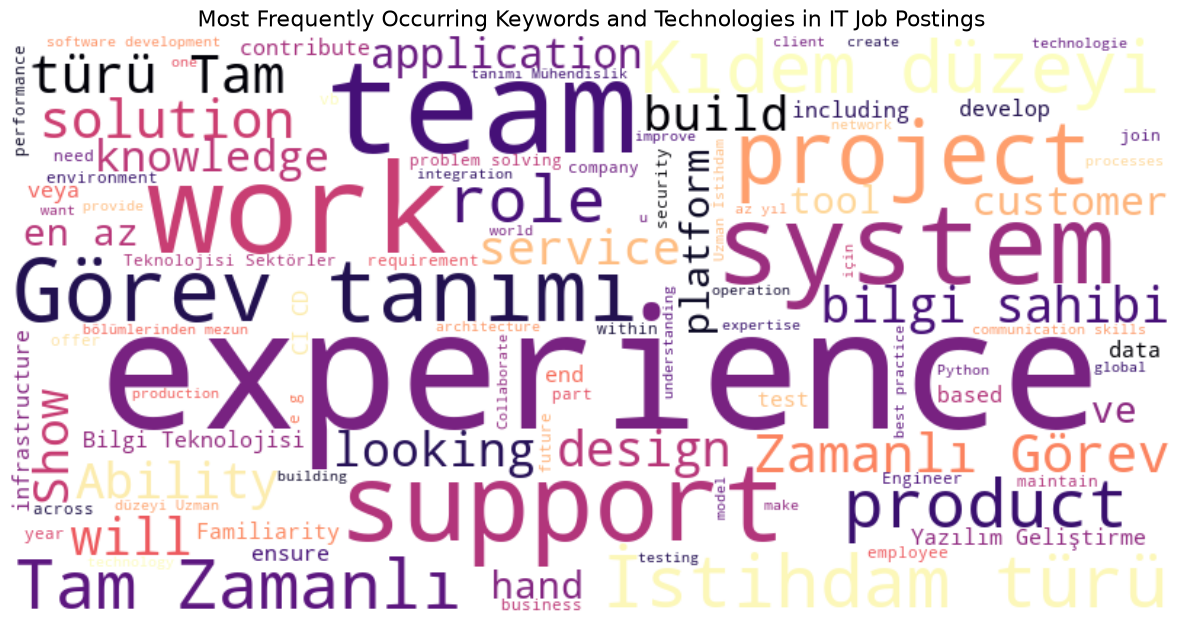

In [20]:
text = " ".join(desc for desc in df_clean['Job_Description'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="magma", max_words=100).generate(text)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequently Occurring Keywords and Technologies in IT Job Postings", fontsize=16)
plt.show()

## Model3 
### Spatial Separation Map with UMAP

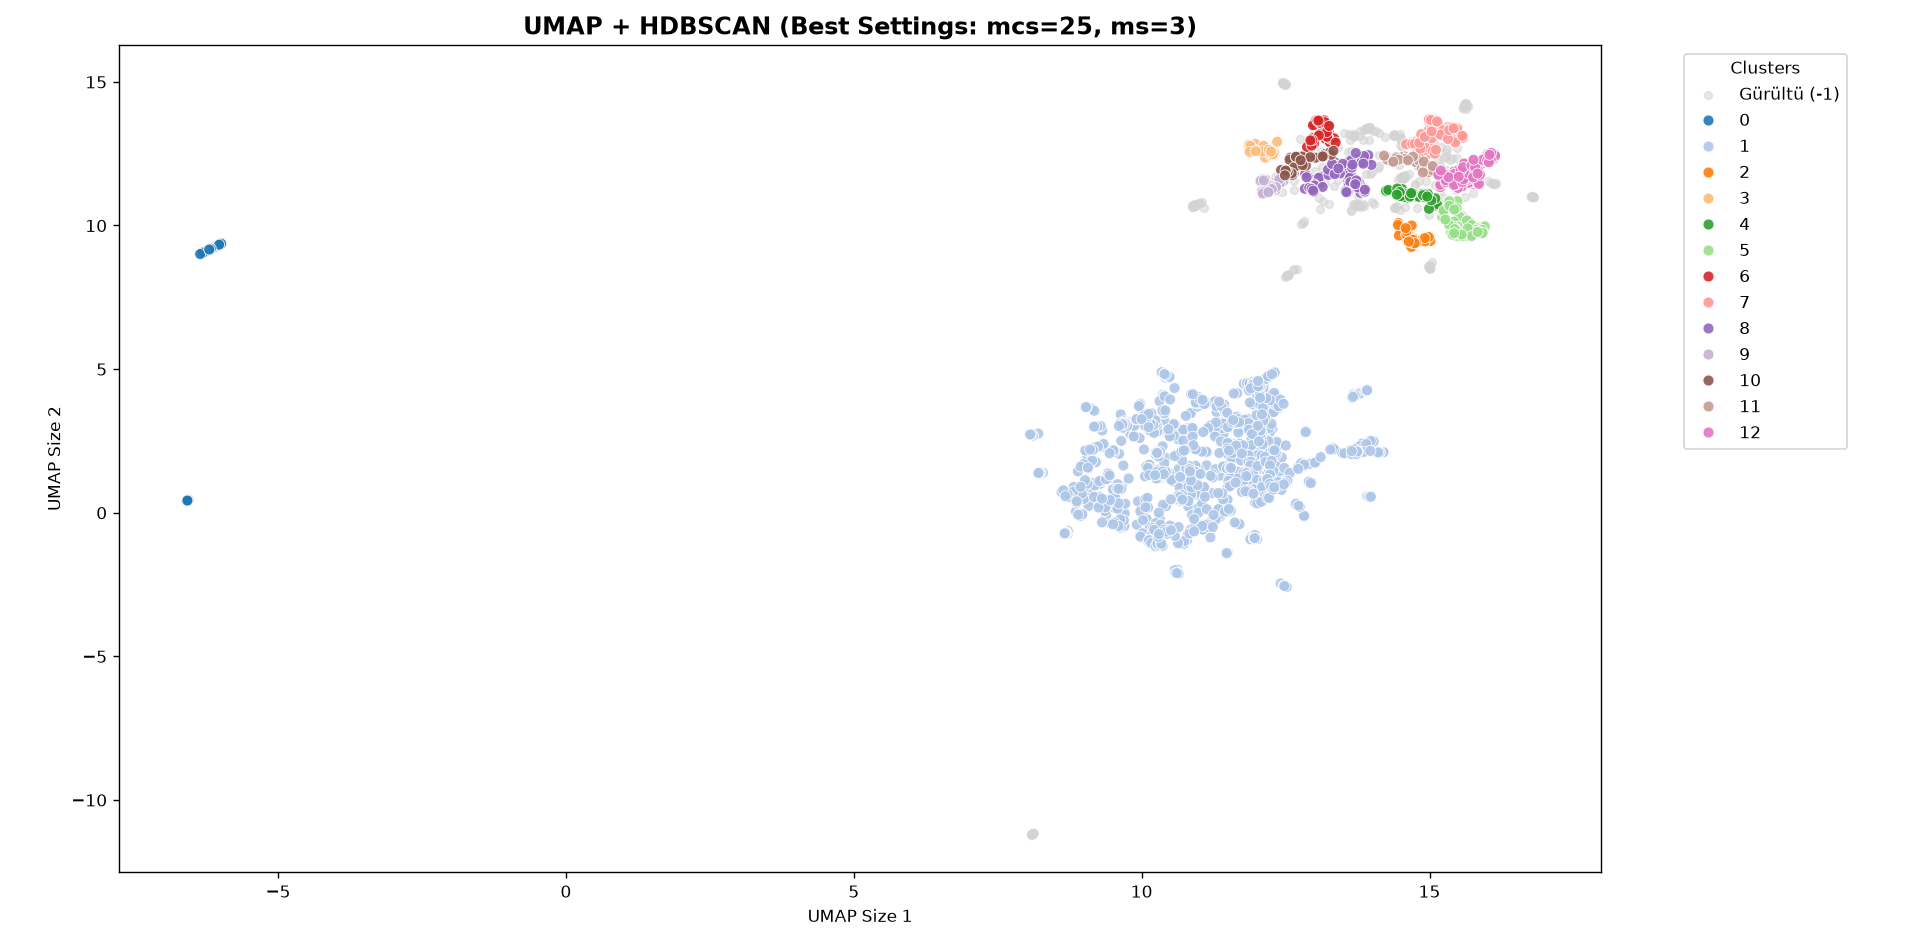